Analyzing most-watched titles...
Analyzing for profile: Katerina


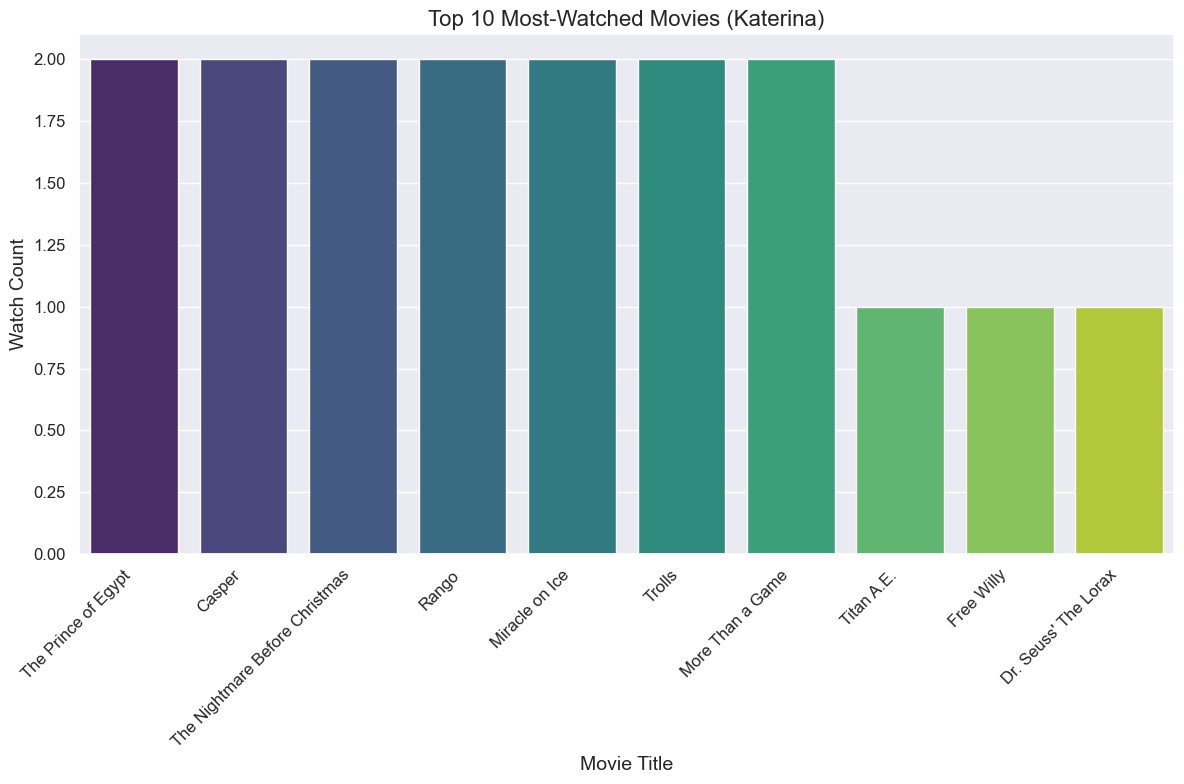

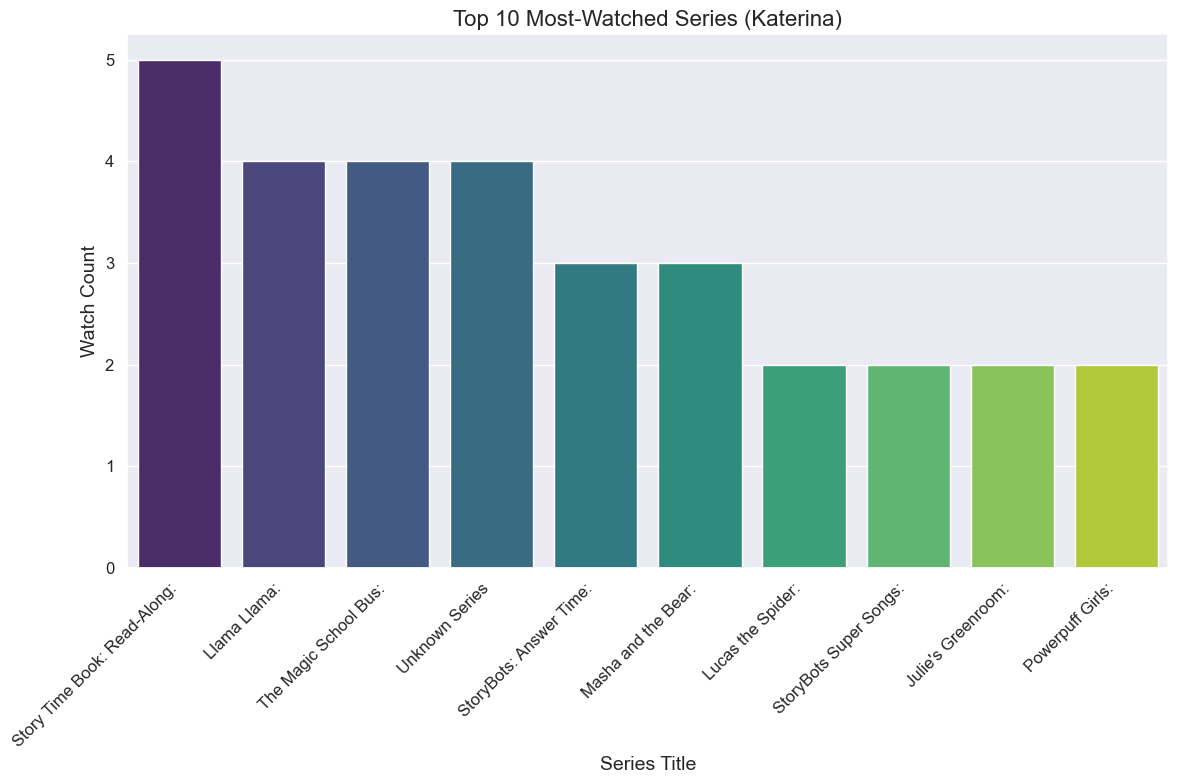

Analyzing for profile: Katerina


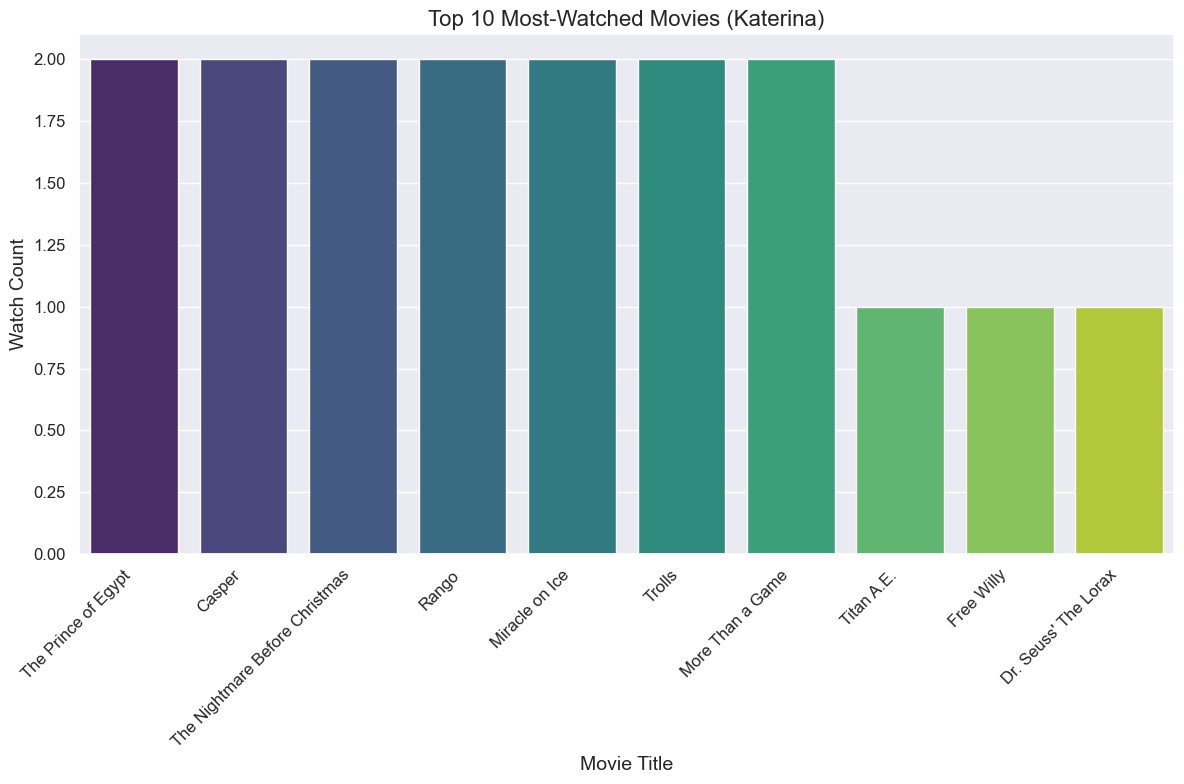

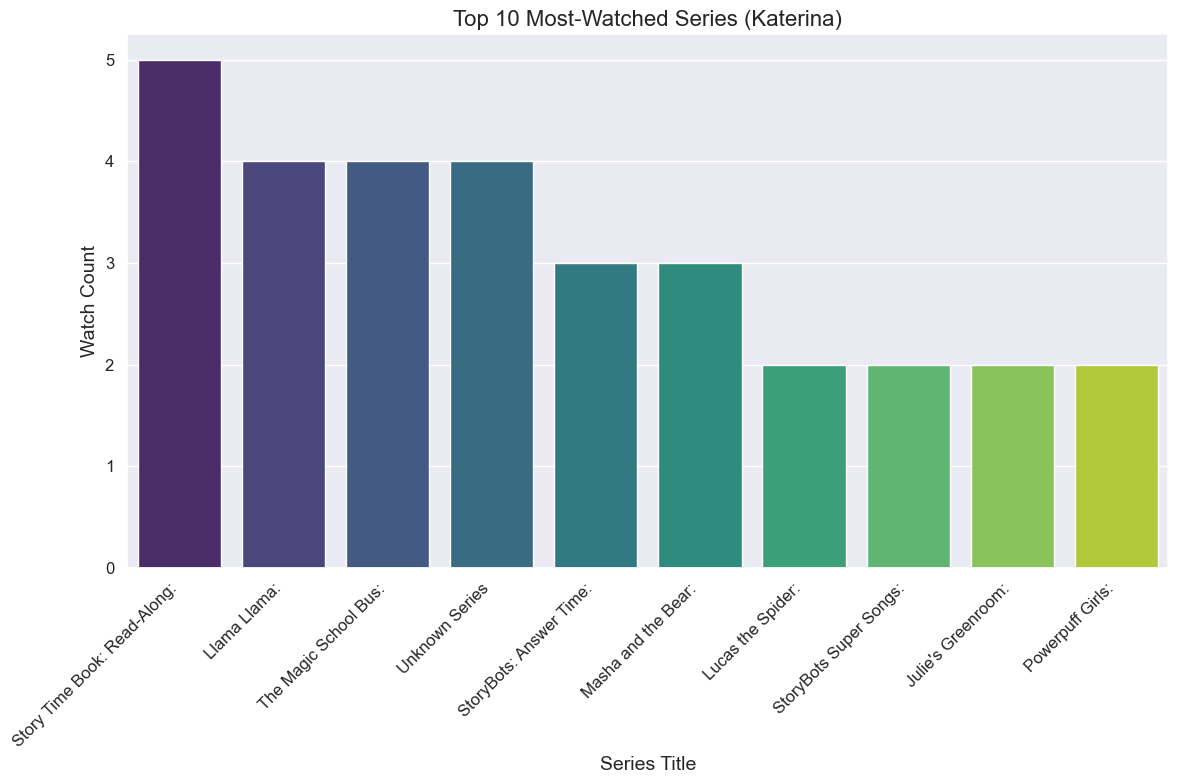

Analyzing for profile: Tristan


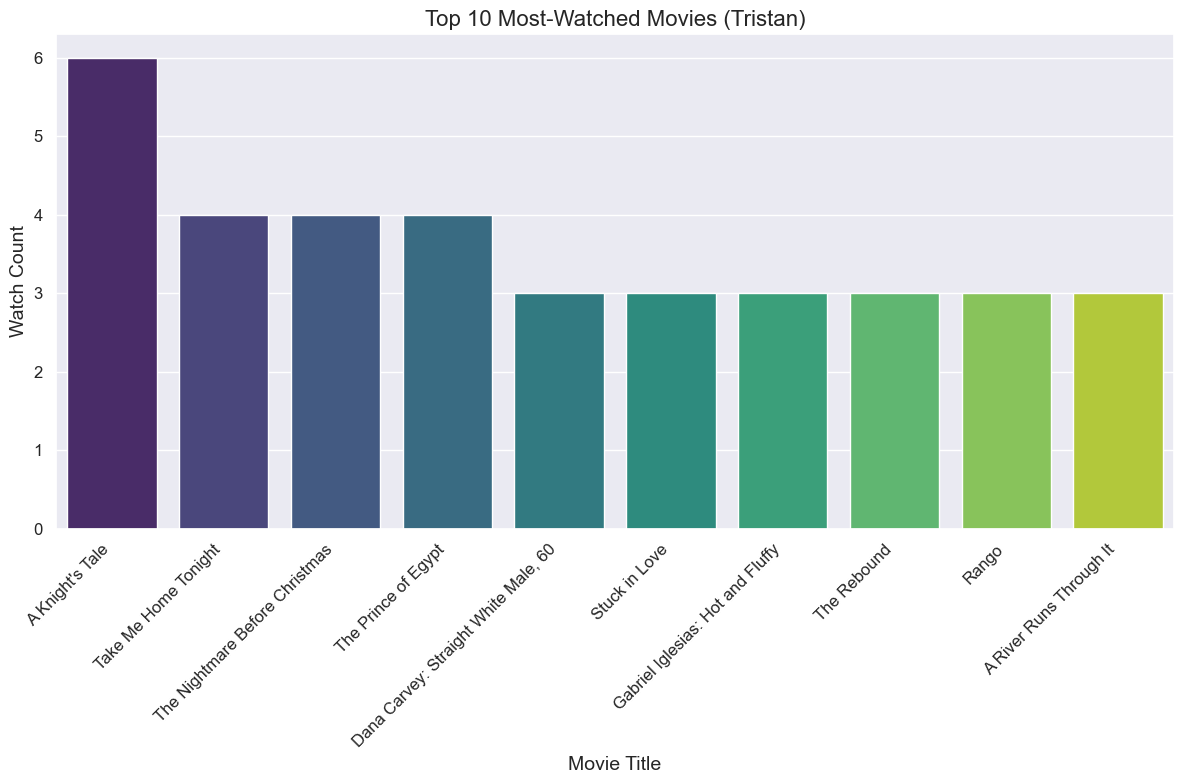

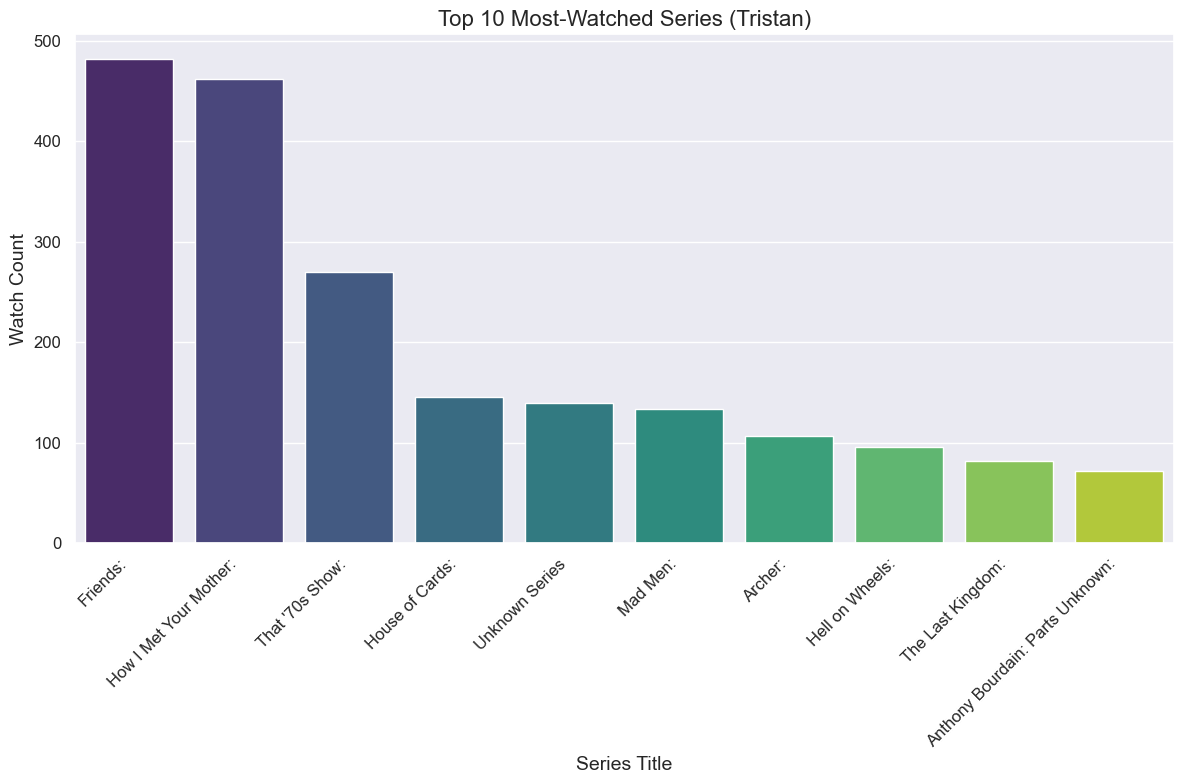

Analyzing for profile: Tristan


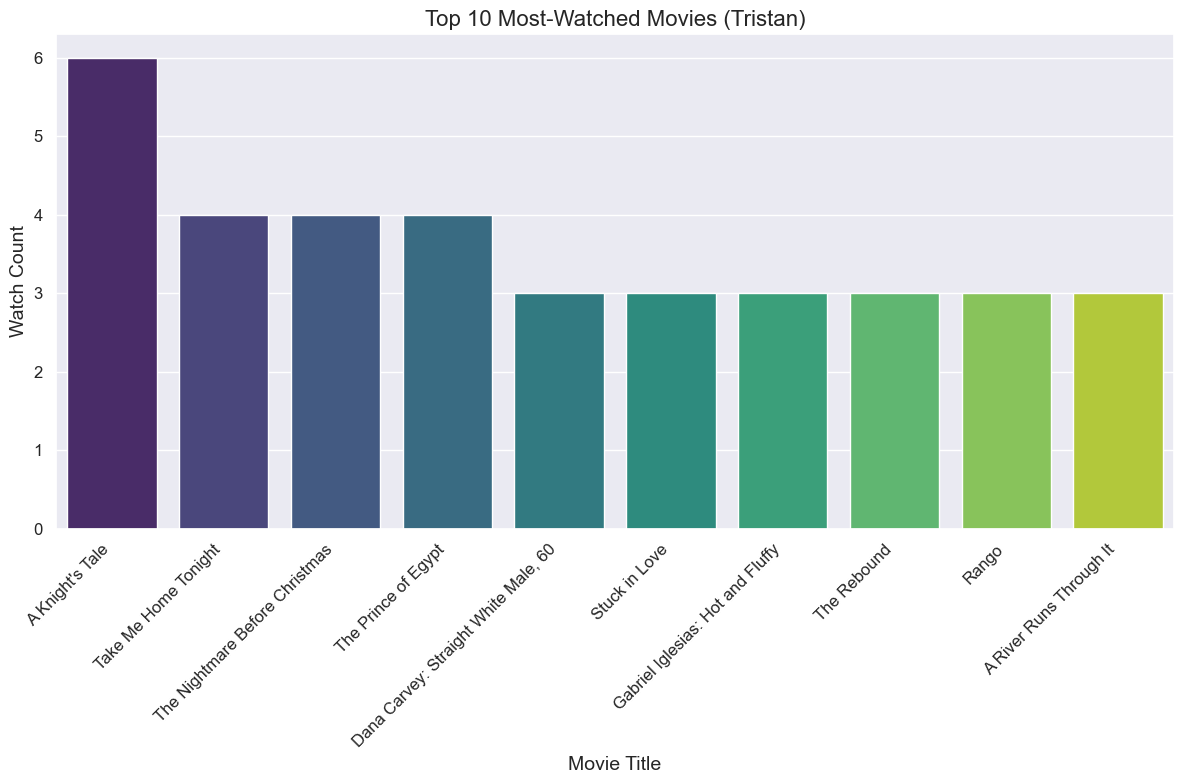

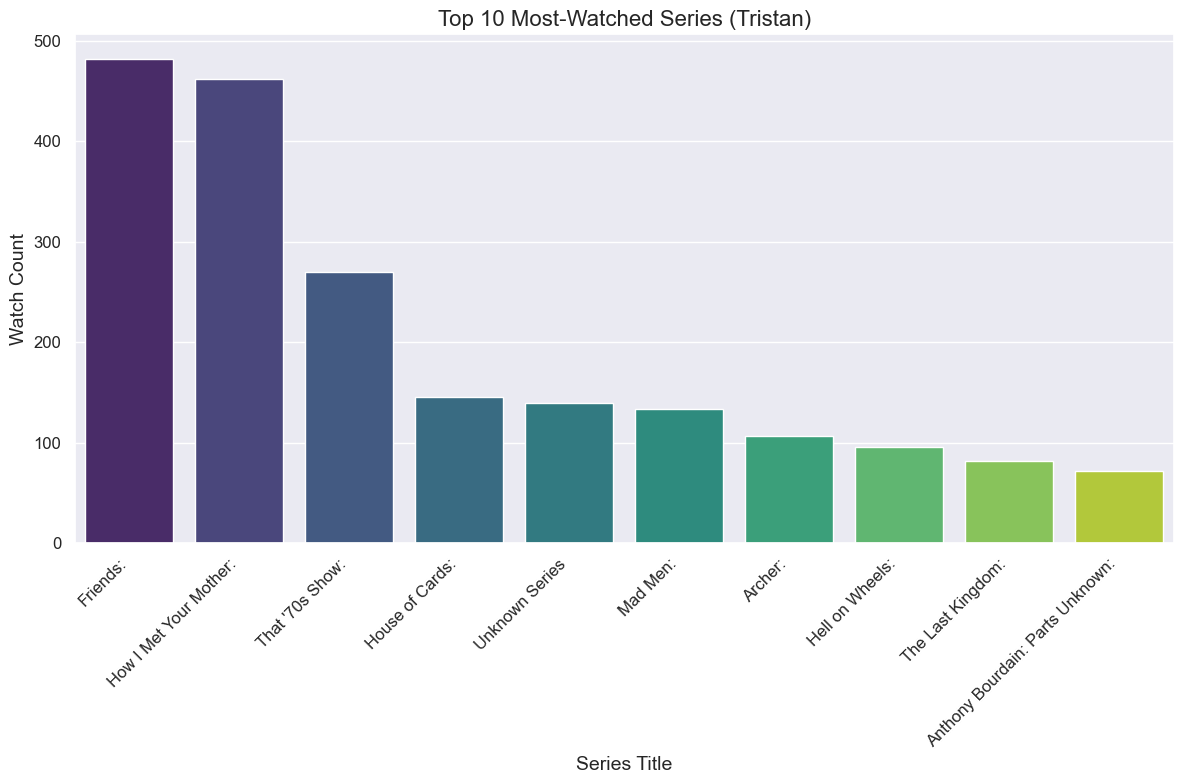

Analyzing for profile: Vanessa


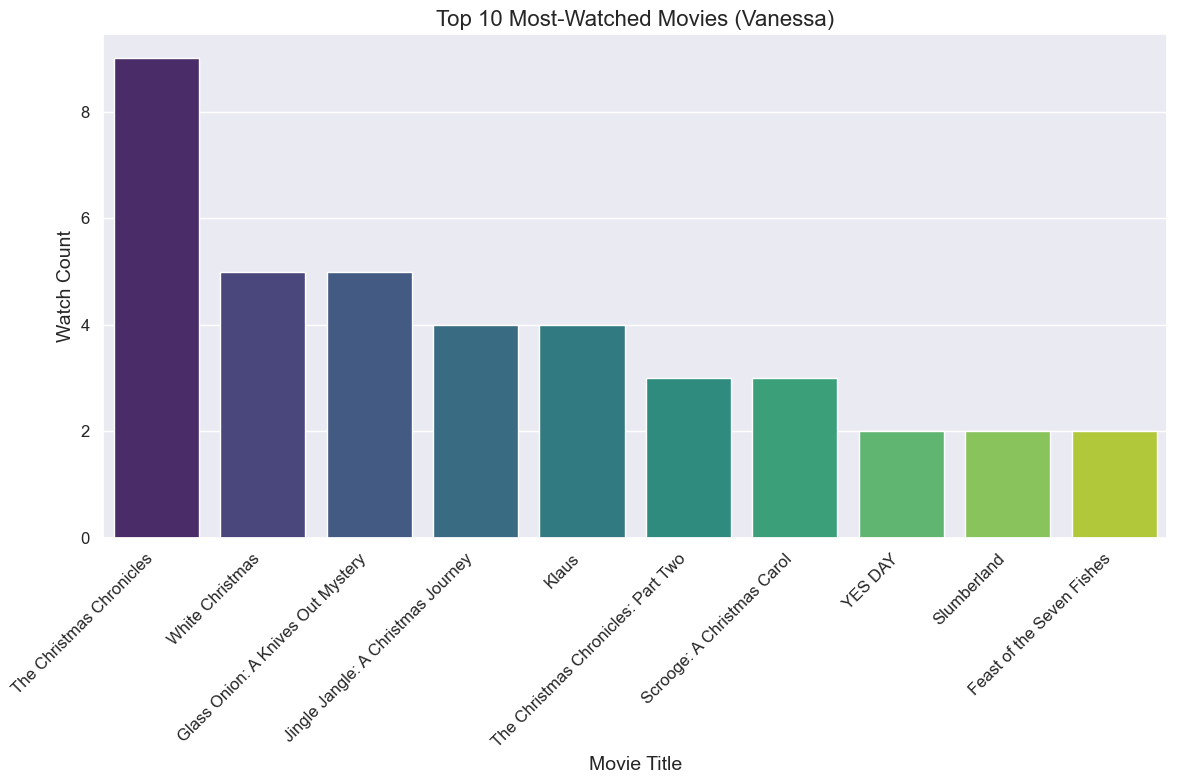

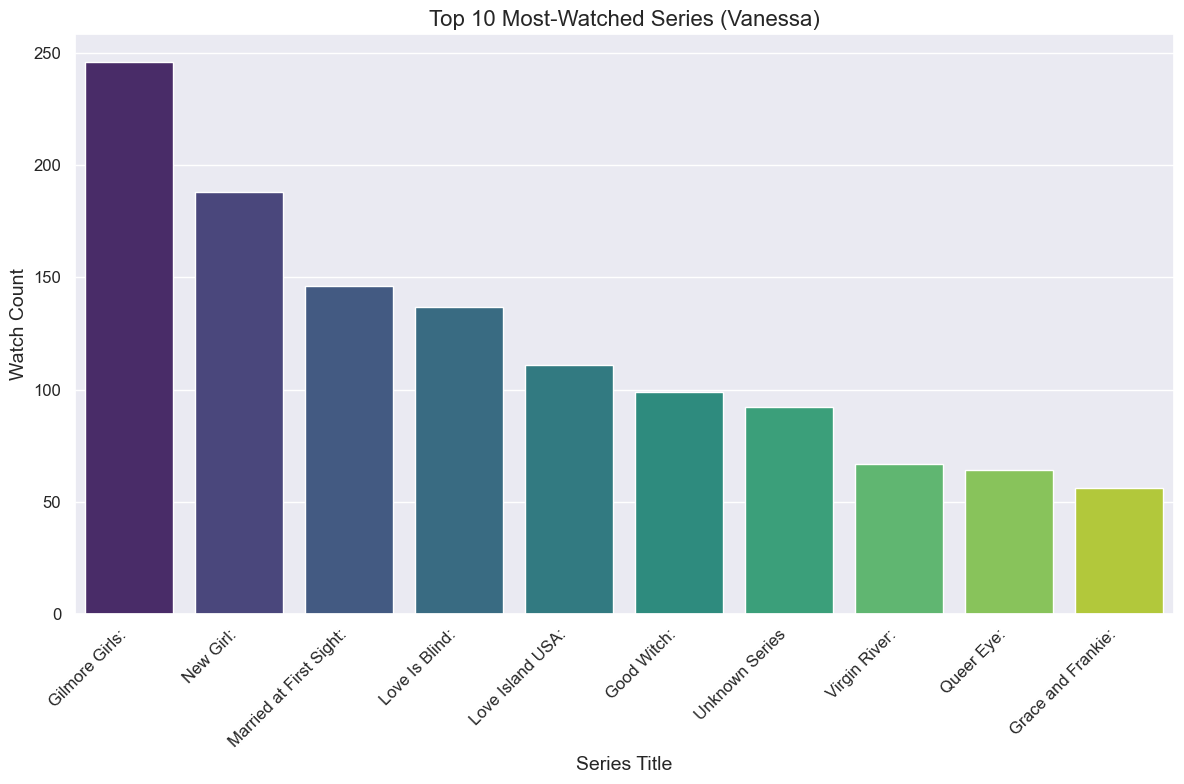

Analyzing for profile: Vanessa


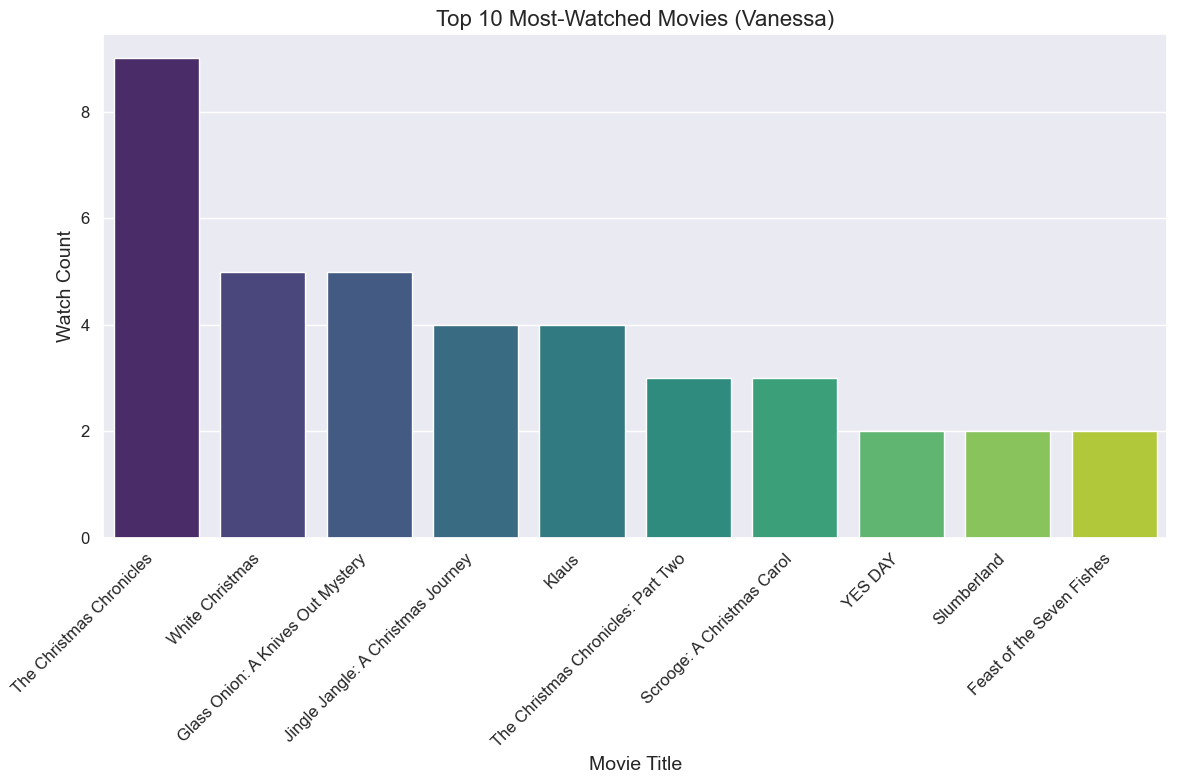

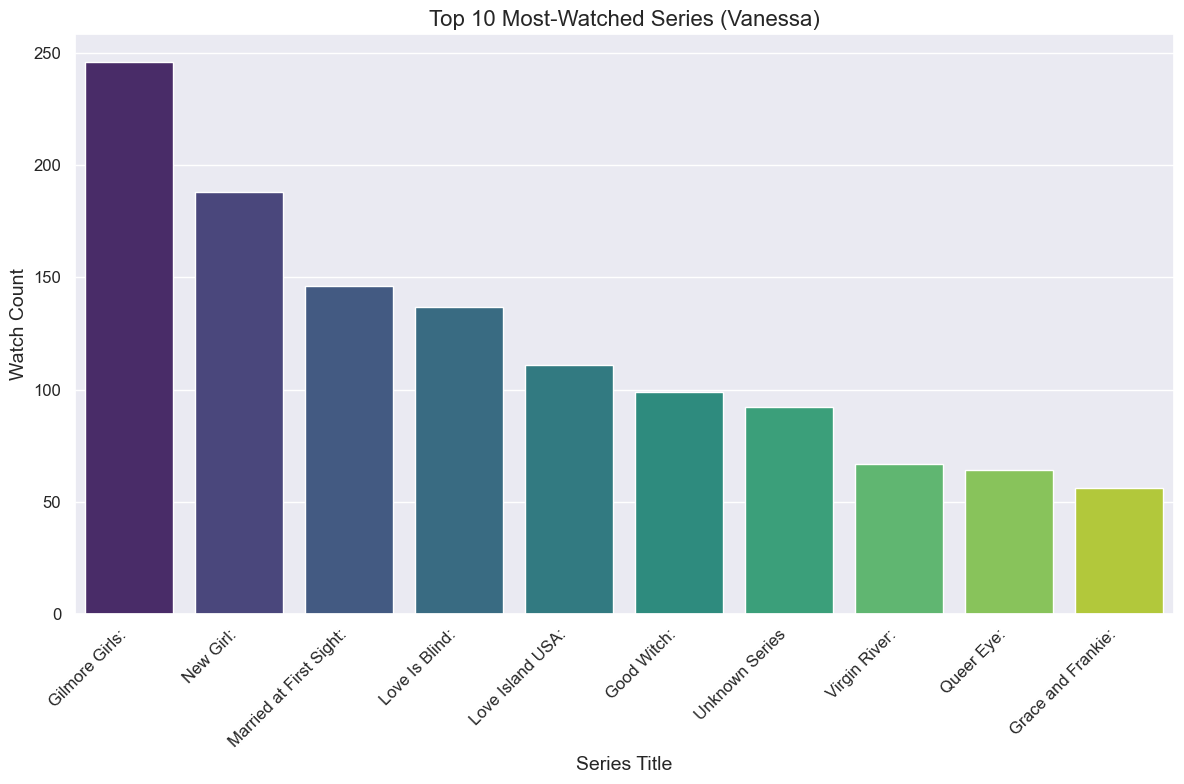

Analyzing viewing habits before and after July 27, 2022...


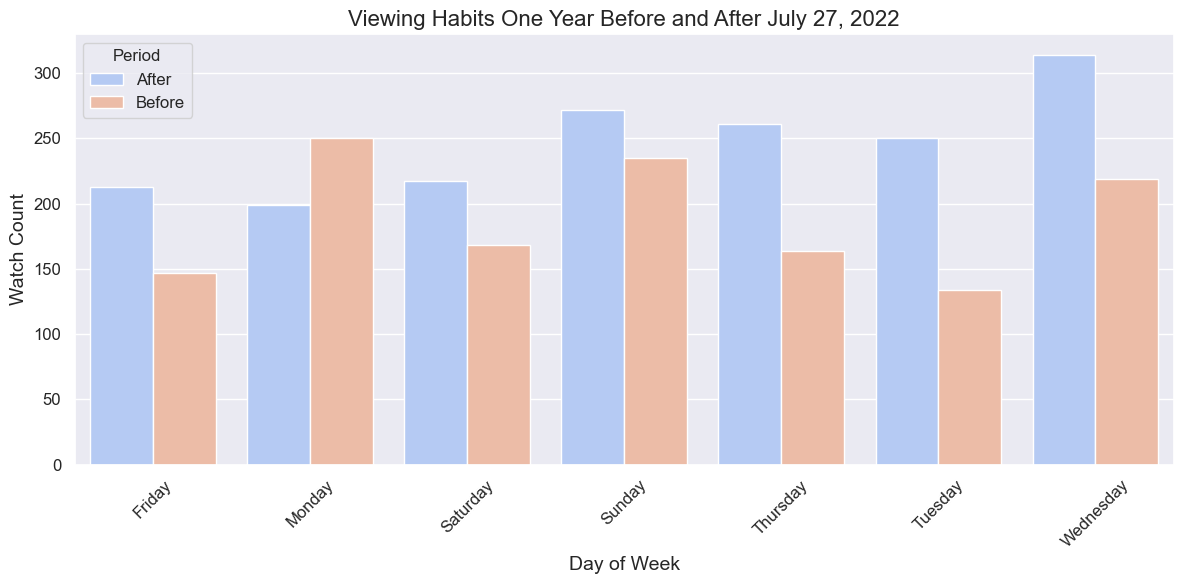

Peak Viewing Times Heatmap


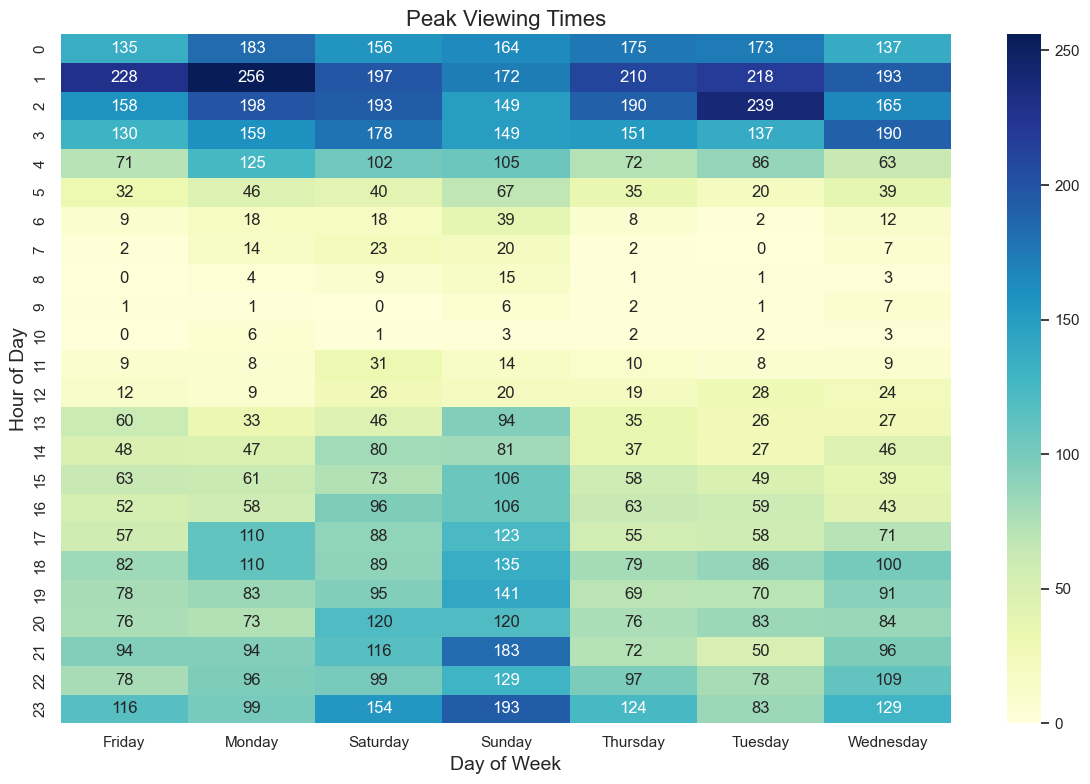

Viewing Duration Distribution: Most common viewing length


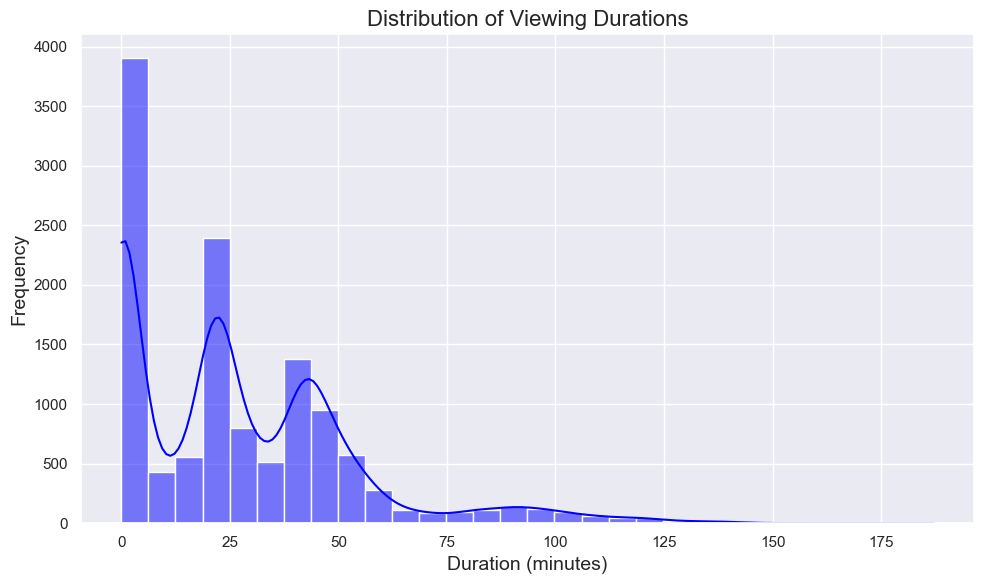

Device Usage


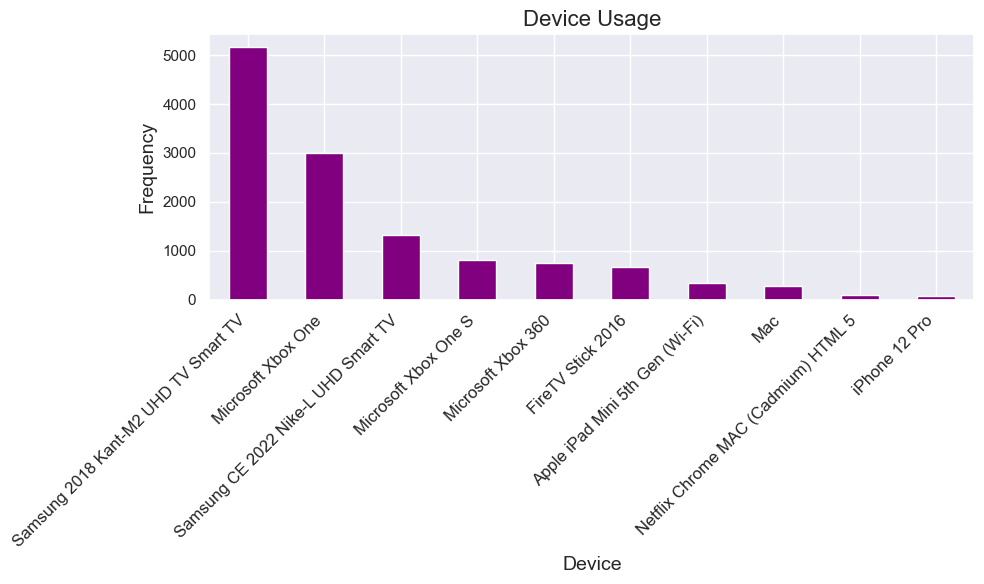

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning and Preprocessing
# Load the raw Netflix viewing data
import os

# Specify the file path
file_path = 'ViewingActivity.csv'

# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")
data = pd.read_csv(file_path)

# Exclude trailers from the dataset
data = data[
    ~((data['Supplemental Video Type'] == 'Trailer') | (data['Title'].str.contains('trailer', case=False, na=False)))]

# Convert "Start Time" to datetime format
data['Start Time'] = pd.to_datetime(data['Start Time'], errors='coerce')


# Convert "Duration" to total seconds for easier analysis
def duration_to_seconds(duration_str):
    try:
        h, m, s = map(int, duration_str.split(':'))
        return h * 3600 + m * 60 + s
    except ValueError:
        return None


data['Duration (seconds)'] = data['Duration'].apply(duration_to_seconds)

# Convert duration from seconds to minutes for easier interpretation
data['Duration (minutes)'] = data['Duration (seconds)'] / 60

# Handle missing values in key columns
data['Attributes'] = data['Attributes'].fillna('Unknown')
data['Supplemental Video Type'] = data['Supplemental Video Type'].fillna('None')

# Extract useful time-based features
data['Year'] = data['Start Time'].dt.year
data['Month'] = data['Start Time'].dt.month
data['Day'] = data['Start Time'].dt.day
data['Hour'] = data['Start Time'].dt.hour
data['Day of Week'] = data['Start Time'].dt.day_name()

# Segment data into "Before Daughter" and "After Daughter" based on milestone date
birthdate = pd.Timestamp('2022-07-27')
data['Before Daughter'] = data['Start Time'] < birthdate

# Save the cleaned dataset
cleaned_file_path = 'Netflix_ViewingActivity_Cleaned.csv'
data.to_csv(cleaned_file_path, index=False)

# Analysis and Visualization
# Load the preprocessed Netflix data
data = pd.read_csv(cleaned_file_path, parse_dates=['Start Time'])

# Set a style for plots
sns.set_theme(style="darkgrid")


# Helper function for creating bar plots
def plot_bar(data, x, y, title, xlabel, ylabel, rotation=0, save_path=None):
    plt.figure(figsize=(12, 8))
    sns.barplot(data=data, x=x, y=y, hue=x, dodge=False, palette="viridis")
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(rotation=rotation, fontsize=12, ha='right')
    plt.yticks(fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# Define classify_title function
def classify_title(row):
    title_lower = row['Title'].lower()
    # List of known movie exceptions
    movie_exceptions = [
        'glass onion: a knives out mystery',
        'the christmas chronicles',
        'miracle on ice',
        'more than a game',
        'the nightmare before christmas'
    ]

    # Check if title matches known movie exceptions
    if title_lower in movie_exceptions:
        return 'Movie'
    # Check for known patterns in series titles
    elif any(keyword in title_lower for keyword in ['season', 'episode']):
        return 'Series'
    # Use duration heuristic: movies are typically longer than 40 minutes (2400 seconds)
    elif row['Duration (seconds)'] > 2400:
        return 'Movie'
    # Default to series for shorter durations
    else:
        return 'Series'


# Apply the refined classification function
data['Category'] = data.apply(classify_title, axis=1)


# Content Analysis: Most-Watched Movies and Series by Profile
def analyze_most_watched_titles():
    import re

    def extract_series_title(title):
        series_title = re.split(r'(season|episode)', title, flags=re.IGNORECASE)[0].strip()
        return series_title if series_title else "Unknown Series"

    filtered_data = data[data['Profile Name'] != 'Guest']
    filtered_data = filtered_data[filtered_data['Title'].notnull() & (filtered_data['Title'].str.strip() != "")]
    profiles = filtered_data['Profile Name'].unique()

    for profile in profiles:
        profile_data = filtered_data[filtered_data['Profile Name'] == profile].copy()
        print(f"Analyzing for profile: {profile}")

        # Most-watched movies
        movie_counts = profile_data[profile_data['Category'] == 'Movie']['Title'].value_counts().head(10).reset_index()
        movie_counts.columns = ['Title', 'Watch Count']
        plot_bar(
            movie_counts, 'Title', 'Watch Count',
            title=f'Top 10 Most-Watched Movies ({profile})',
            xlabel='Movie Title', ylabel='Watch Count', rotation=45,
            save_path=f'most_watched_movies_{profile}.png'
        )

        # Most-watched series
        profile_data['Series Title'] = profile_data['Title'].apply(extract_series_title)
        series_counts = profile_data[profile_data['Category'] == 'Series'] \
            .groupby('Series Title')['Title'] \
            .count() \
            .sort_values(ascending=False) \
            .head(10) \
            .reset_index()
        if series_counts.empty:
            print(f"No series data to plot for profile: {profile}")
            continue
        series_counts.columns = ['Title', 'Watch Count']
        plot_bar(
            series_counts, 'Title', 'Watch Count',
            title=f'Top 10 Most-Watched Series ({profile})',
            xlabel='Series Title', ylabel='Watch Count', rotation=45,
            save_path=f'most_watched_series_{profile}.png'
        )
        profile_data = filtered_data[filtered_data['Profile Name'] == profile].copy()
        print(f"Analyzing for profile: {profile}")

        # Most-watched movies
        movie_counts = profile_data[profile_data['Category'] == 'Movie']['Title'].value_counts().head(10).reset_index()
        movie_counts.columns = ['Title', 'Watch Count']
        plot_bar(
            movie_counts, 'Title', 'Watch Count',
            title=f'Top 10 Most-Watched Movies ({profile})',
            xlabel='Movie Title', ylabel='Watch Count', rotation=45
        )

        # Most-watched series
        profile_data['Series Title'] = profile_data['Title'].apply(extract_series_title)
        series_counts = profile_data[profile_data['Category'] == 'Series'] \
            .groupby('Series Title')['Title'] \
            .count() \
            .sort_values(ascending=False) \
            .head(10) \
            .reset_index()
        if series_counts.empty:
            print(f"No series data to plot for profile: {profile}")
            continue
        series_counts.columns = ['Title', 'Watch Count']
        plot_bar(
            series_counts, 'Title', 'Watch Count',
            title=f'Top 10 Most-Watched Series ({profile})',
            xlabel='Series Title', ylabel='Watch Count', rotation=45
        )


# Time Analysis: Viewing Habits Before and After July 27, 2022
def analyze_viewing_habits(save_path="viewing_habits.png"):
    # Define the time range: two years before and two years after
    start_date = pd.Timestamp('2021-07-27')
    end_date = pd.Timestamp('2023-07-27')
    filtered_data = data[(data['Start Time'] >= start_date) & (data['Start Time'] <= end_date)]

    # Group by "Before Daughter" and "Day of Week"
    viewing_counts = filtered_data.groupby(['Before Daughter', 'Day of Week'])['Title'].count().reset_index()
    viewing_counts.columns = ['Before Daughter', 'Day of Week', 'Watch Count']

    # Map True/False to Before/After for clarity
    viewing_counts['Before Daughter'] = viewing_counts['Before Daughter'].map({True: 'Before', False: 'After'})

    # Plot the data
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=viewing_counts, x='Day of Week', y='Watch Count',
        hue='Before Daughter', palette='coolwarm'
    )
    plt.title('Viewing Habits One Year Before and After July 27, 2022', fontsize=16)
    plt.xlabel('Day of Week', fontsize=14)
    plt.ylabel('Watch Count', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title='Period', fontsize=12)
    plt.tight_layout()
    plt.show()


# Peak Viewing Times: Analyze the time of day and days of the week with the most viewing activity
# Create a heatmap to visualize trends
def analyze_peak_viewing_times(save_path=None):
    # Group data by hour and day of week
    peak_times = data.groupby(['Hour', 'Day of Week'])['Title'].count().unstack()

    # Convert values to integers to match the expected format for fmt="d"
    peak_times = peak_times.fillna(0).astype(int)

    plt.figure(figsize=(12, 8))
    sns.heatmap(peak_times, cmap="YlGnBu", annot=True, fmt="d")
    plt.title("Peak Viewing Times", fontsize=16)
    plt.xlabel("Day of Week", fontsize=14)
    plt.ylabel("Hour of Day", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# Viewing Duration Distribution: Analyze trends in how long content is watched
def analyze_viewing_durations(save_path=None):
    plt.figure(figsize=(10, 6))
    sns.histplot(data['Duration (minutes)'], bins=30, kde=True, color='blue')
    plt.title("Distribution of Viewing Durations", fontsize=16)
    plt.xlabel("Duration (minutes)", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# Device Usage: Analyze the devices used most frequently for watching Netflix
# Create a bar chart of the top 10 devices
def analyze_device_usage(save_path=None):
    device_counts = data['Device Type'].value_counts().head(10)
    plt.figure(figsize=(10, 6))
    device_counts.plot(kind='bar', color='purple')
    plt.xticks(rotation=45, fontsize=12, ha='right')
    plt.title("Device Usage", fontsize=16)
    plt.xlabel("Device", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# Call functions for analysis
if __name__ == "__main__":
    print("Analyzing most-watched titles...")
    analyze_most_watched_titles()

    print("Analyzing viewing habits before and after July 27, 2022...")
    analyze_viewing_habits()

    print("Peak Viewing Times Heatmap")
    analyze_peak_viewing_times(save_path="peak_viewing_times.png")

    print("Viewing Duration Distribution: Most common viewing length")
    analyze_viewing_durations(save_path="viewing_duration_distribution.png")

    print("Device Usage")
    analyze_device_usage(save_path="device_usage.png")
